### <h1 align="center">Fig. 1g: Curve fitting with exponential function</h1>

This script is used to fit an exponential fit function to the chromosome-to-chromosome distance of the *C. elegans* spindle during mitosis.

The following exponential function is implemented in this script:
<h1>
\begin{equation*}
y = a(1 - e^{-x/b})
\end{equation*}
</h1>

The following parameters are extracted from the fitting:

* Final segregation length (Final chromosome-to-chromosome distance)
* Segregation rate (Speed of chromosome-to-chromosome segregation distance)

**`Input`:** *.CSV* file containing the data of the chromosome-to-chromosome distance over time for each experiment.

The table below shows the table structure of each .csv file. The headers of each table should show the time series measurement value from each observation which starts with prefix, **Exp**, and other statistical values from the observations.

|Exp00 | Exp01 | Exp02 | Exp03 | Exp04 | Exp05 | mean | std | n | SE | time |
| :-----: | :-----: | :-----: | :-----: | :-----: | :-----: | :-----: | :-----: | :-----:| :-----: | :-----: |
| `num` | `num` | `num` | `num` | `num` | `num` | `num` | `num` |`num` | `num` | `num` |
| `...` | `...` | `...` | `...` | `...` | `...` | `...` | `...` |`...` | `...` | `...` |


**`OUTPUT FILES`**

A **.PNG** file showing the fitted plots and a **.CSV** file containing the extracted parameters from the fitting.

In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
# input folder
folder = r'D:\data\Analysis Data\python_analysis\input'
fileTable = os.listdir(folder)

# # output folder
save_files = r'D:\data\Analysis Data\python_analysis\output'

In [4]:
# read out the input files
file_list = {}
for file in fileTable:
    filepath = os.path.join(folder, file)
    filename = os.path.basename(filepath)

    file_container = [
        '32-cell_ABalpa_pole_to_pole.csv',
        '32-cell_ABalpa_chromatid_to_chromatid.csv'
    ]

    if filename in file_container:
        try:
            df = pd.read_csv(filepath, index_col=None, encoding='utf-8')
        except:
            df = pd.read_csv(filepath, index_col=None, encoding='cp1252')

        key = filename.replace('.csv', '')
        file_list[key] = df

In [5]:
# check the loaded file
file_list['32-cell_ABalpa_chromatid_to_chromatid'].head(3)

,Exp20cc,Exp28cc,Exp29cc,Exp32cc,Exp42cc,Exp45cc,mean,median,std,n,SE,time
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00,0.000000,6,0.000000,0.0
1,2.2,1.5,2.7,1.5,2.7,2.5,2.183333,2.35,0.511262,6,0.208722,10.3
2,4.1,3.0,4.3,3.0,3.9,3.5,3.633333,3.70,0.508811,6,0.207721,20.6


In [8]:
# extract the time, data, mean, standard deviation columns and create a new dataframe
file_of_interest = file_list['32-cell_ABalpa_chromatid_to_chromatid']
time_column = file_of_interest.loc[:, file_of_interest.columns.str.startswith('time')]
data_table = file_of_interest.loc[:, file_of_interest.columns.str.contains('Exp')]
mean_table = file_of_interest.loc[:, file_of_interest.columns.str.contains('mean')]
std_table = file_of_interest.loc[:, file_of_interest.columns.str.contains('std')]

df1 = pd.concat([time_column, data_table], axis=1)
df2 = pd.concat([time_column, mean_table], axis=1)
df3 = pd.concat([time_column, std_table], axis=1)
main_table = pd.concat([time_column, data_table, mean_table, std_table], axis=1)

In [9]:
# check new df
main_table_dropna = main_table.dropna(thresh=3)
main_table_dropna.head(3)

,time,Exp20cc,Exp28cc,Exp29cc,Exp32cc,Exp42cc,Exp45cc,mean,std
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,10.3,2.2,1.5,2.7,1.5,2.7,2.5,2.183333,0.511262
2,20.6,4.1,3.0,4.3,3.0,3.9,3.5,3.633333,0.508811


### Exponential function
Fit an exponential function to the data to determine the final chromosome distance and the rate of chromosome segregation distance

In [13]:
'''
a = initial amplitude of the function
b = time constant (the time taken for the function to reach approximately 63.2% of its maximum value,
'''

def exponential(x, a, b):
        return a * (1 - np.exp(-x / b))

# define x-values and y-values
x = main_table_dropna['time']
y_mean = main_table_dropna['mean']

# compute the initial guess
initial_guess = [10, 50]

# summarize the parameter
popt, pcov = curve_fit(exponential, x, y_mean, initial_guess, maxfev=10000)

''' 
Define a sequence of inputs between the smallest and largest known inputs and define the fit. 
Let the maximum input assume the maximum values of x. 
'''
# x_fit = np.arange(0, x.max()+0.1, 0.1, dtype=None)
x_fit = np.arange(0, x.max()+1, 1, dtype=None)
y_fit = exponential(x_fit, *popt)
# print(len(y_fit))

# assign variables to the fit parameter output
amp = popt[0]
T = popt[1]

# determine the slope == segregation speed
segregation_speed = (amp/T)*60 # convert to µm/min by multiplying by 60
final_C_C_length = amp

# create a table for the speed of segregation and the maximum distance
parameters = {'Final chromosomes length (µm)': final_C_C_length,
              'Segregation speed (µm/min)': segregation_speed
              }
fit_Result = pd.DataFrame()
parameters_df = pd.DataFrame.from_dict(parameters, orient='index', columns=['32-cell_ABalpa_fit_values'])
fit_Result = pd.concat([fit_Result, parameters_df], axis=1)

fit_Result.index.names = ['fit_parameter']
fit_Result.to_csv(os.path.join(save_files, '32-cell_ABalpa_Chromosome_to_chromosome_fit.csv'), encoding='cp1252')
# final_C_C_length, segregation_speed

207


In [11]:
# fit_table = {'time (s)': x_fit, 'fit value: chromosome-to-chromosome distance (µm)': y_fit}
# fit_table_df = pd.DataFrame.from_dict(fit_table, orient='columns')
# fit_table_df.to_csv(os.path.join(save_files, 'WT C-C distances fit values.csv'), index=False, encoding='cp1252')

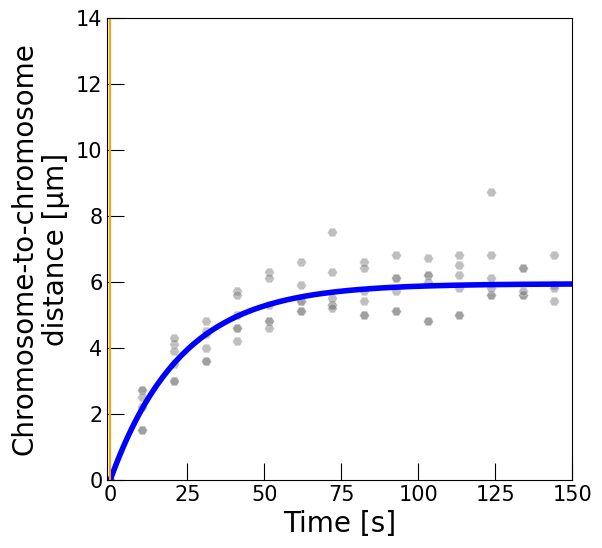

In [16]:
sns.set_style(style=None)
plt.figure(figsize=(6,6))

# iterate through the data columns
cells= [columnname for columnname in main_table_dropna if columnname.startswith('Exp')]

# plot the primary data
for i_columns in cells: 
    ax = sns.scatterplot(data=main_table_dropna, x=x, y=i_columns, color='grey', marker='H', alpha=0.5, s=52)
    # ax = sns.scatterplot(data=main_table_dropna, x=x, y=i_columns, color='grey', marker='o', alpha=0.5, s=52, legend=True, label='Raw data')

# plot the fit on the primary plot
sns.lineplot(x=x_fit, y=y_fit, alpha = 1, color='blue', linewidth=4, ax=ax)
# sns.lineplot(x=x_fit, y=y_fit, alpha = 1, color='blue', linewidth=4, ax=ax, legend=True, label='fit')

# add a vertical line at time 0 sec to indicate anaphase onset
ax.vlines(x=0, ymin=-1, ymax=30, linestyle='solid', color='orange', alpha=1)

# add the desired features on the plot
ax.set_xlabel('Time [s]', fontsize= 20)
ax.set_ylabel('Chromosome-to-chromosome\ndistance [μm]', fontsize= 20) 
ax.tick_params(axis='both', which='major', labelsize=15, direction='in', size=12)
# ax.tick_params(axis='both', which='major', labelsize=15)
# ax.tick_params(axis='x', direction='in', length=8)
# ax.tick_params(axis='y', direction='in', length=8)

# # remove duplicates labels in the legend
# handles, labels = ax.get_legend_handles_labels()
# unique_labels = dict(zip(labels, handles))
# ax.legend(unique_labels.values(), unique_labels.keys())

ax.set(ylim=(0, 13.5+.5), xlim=(-1, 150))
# ax.figure.savefig(os.path.join(save_files, 'Chromosome-to-chromosome_distances (All dataset).png'), dpi=600, bbox_inches='tight')
ax.figure.savefig(os.path.join(save_files, '32-cell_ABalpa_Chromosome_distances.png'), dpi=600, bbox_inches='tight')